![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [104]:
import warnings
warnings.filterwarnings('ignore')

In [105]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [106]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [107]:
# Celda 1.1
bikes.groupby('season').total.mean()

,total
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


In [108]:
bikes.groupby('season').total.describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [109]:
# Celda 1.2
bikes.groupby('hour').total.mean()

,total
hour,
0,55.138462
1,33.859031
2,22.899554
3,11.757506
4,6.407240
5,19.767699
6,76.259341
7,213.116484
8,362.769231


In [110]:
bikes.groupby('hour').total.describe()

,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0


En cuanto a la variable season, se observan variaciones significativas tanto en la demanda promedio como en la dispersión del número de alquiler de bicicletas a lo largo del año. Verano (3) y otoño (4) presentan los mayores promedios, así como valores máximos y percentiles superiores (75%) más altos, lo cual puede deberse a condiciones climáticas más favorables para el uso de bicicletas. Por el contrario, el invierno (1) presenta valores máximos y percentiles considerablemente menores, evidenciando no solo una menor demanda sino también una menor variablidad, posiblemente a causa de las bajas temperaturas.

Por otro lado, la variable hour presenta un comportamiento no lineal con un patrón bimodal. Se identifican dos picos pronunciados en la demanda, uno en las horas de la mañana (entre las 7-9) y otro en la tarde (entre las 16-19). En estas horas se observan mayores valores máximos y mayor dispersión entre los percentiles 25% y 75%. Durante las horas intermedias (9-13) la demanda es moderada, mientras que en la madrugada la demanda es significativamente baja y con poca variabilidad. Este comportamiento está posiblemente asociado a los horarios laborales (de ingreso o salida de los usuarios.

Este análisis sugiere que las variables season y hour son altamente relevantes para la predicción del alquiler de bicicletas al reflejar de manera significativa el comportamiento de los usuarios.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: title={'center': 'Promedio de bicicletas rentadas por hora a lo largo del año'}, xlabel='hour'>

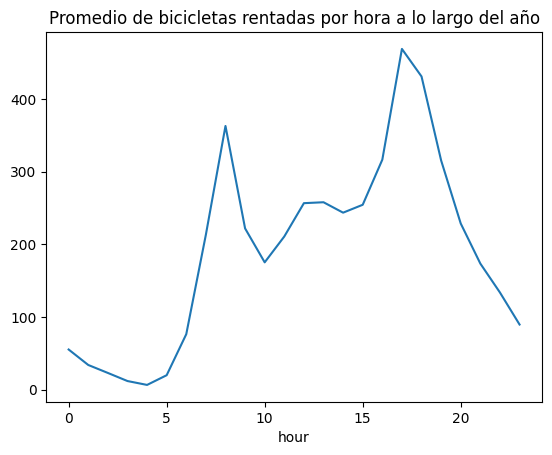

In [111]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot(title='Promedio de bicicletas rentadas por hora a lo largo del año')

<Axes: title={'center': 'Promedio de bicicletas rentadas por hora en invierno'}, xlabel='hour'>

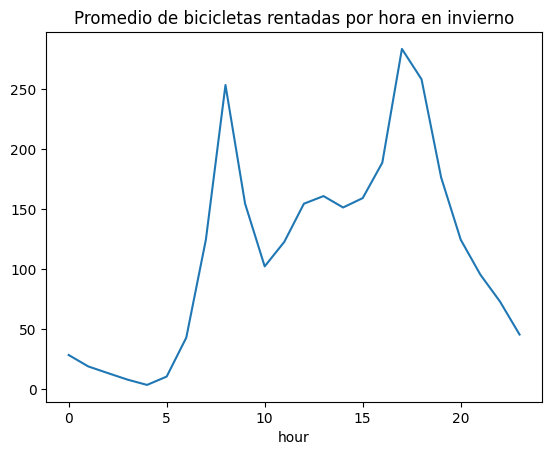

In [112]:
# Celda 2.2 - "season"=1[Invierno] escriba su código y hallazgos
bikes[bikes['season'] == 1].groupby('hour').total.mean().plot(title='Promedio de bicicletas rentadas por hora en invierno')

<Axes: title={'center': 'Promedio de bicicletas rentadas por hora en verano'}, xlabel='hour'>

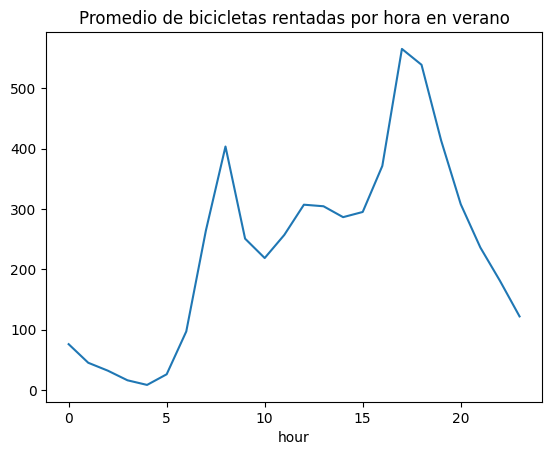

In [113]:
# Celda 2.3 - "season"=3[Verano] escriba su código y hallazgos
bikes[bikes['season'] == 3].groupby('hour').total.mean().plot(title='Promedio de bicicletas rentadas por hora en verano')

Se observa que el promedio de bicicletas rentadas por hora en invierno (season = 1)conserva el patrón bimodal identificado previamente, aunque con una reducción considerable en la demanda. Los picos en las horas de la mañana y la tarde son menos pronunciados y el número de alquileres es significativamente más bajo a lo largo de todo el día.

Por otro lado, en verano (season = 3), se evidencia un claro aumento en los alquileres por hora. Los picos en las horas de la mañana y la tarde son mucho más pronunciados, alcanzando valores significativamente superiores en comparación con el invierno. Además, se observa una mayor demanda en horas intermedias del día.

Se evidencia una clara interacción entre ambas variables, sugiriendo que el impacto de la hora del día sobre la demanda de bicicletas depende de la estación del año.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [114]:
# Celda 3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = bikes[['season', 'hour']]
y = bikes['total']

#Separación train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

#Convertir variable categórica (season) en dummies porque no conviene usar factorize
X_train = pd.get_dummies(X_train, columns=['season'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['season'], drop_first=True)

#Modelo
model = LinearRegression()
model.fit(X_train, y_train)

#Coeficientes
coef_df = pd.DataFrame({'variable': X_train.columns,'coeficiente': model.coef_})
coef_df

,variable,coeficiente
0,hour,10.683605
1,season_2,100.281955
2,season_3,114.874439
3,season_4,87.131401


El coeficiente correspondiente a la variable dummy season = 1 (invierno) no se ve reflejado explícitamente, ya que esta categoría fue utilizada como referencia para evitar que la regresión lineal asuma relaciones numéricas o interprete incorrectamente un orden entre las categorías. Por lo tanto, los coeficientes estimados para las demás estaciones representan diferencias en el número promedio de bicicletas rentadas en comparación con el invierno.

El coeficiente de la variable hour indica que, en promedio, por cada aumento de 1 hora, el número de bicicletas rentadas aumenta en 10.68 unidades, manteniendo constantes las demás variables.

En cuanto a la variable season, los coeficientes muestran que todas las estaciones presentan un mayor alquiler en comparación con el invierno. El verano (season = 3) presenta el mayor coeficiente, con 114.87 bicicletas adicionales en promedio, seguido de la primavera con 100.28 y el otoño con 87.13.

Las limitaciones del modelo de regresión en este caso son su incapacidad para capturar las relaciones no lineales, como el patrón bimodal observado en la variable hour. Asimismo, el modelo no considera las interacciones entre variables, como la interacción entre hour y season, lo cual limita su capacidad para representar adecuadamente la dinámica real de los datos y, por ende, su desempeño predictivo.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [115]:
# Celda 4
#Definir variables
X = bikes[['hour', 'season']]
y = bikes['total']

#MSE
def mse(y):
    if len(y) == 0:
        return 0
    return np.mean((y - y.mean())**2)

#Impurity
def mse_impurity(X_col, y, split):

    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]

    n_l = y_l.shape[0]
    n_r = y_r.shape[0]

    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)

    mse_impurity_ = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)

    return mse_impurity_

#Mejor split
def best_split(X, y, num_pct=10):

    features = range(X.shape[1])

    best_split = [0, 0, 0]  # j, split, gain

    for j in features:

        splits = np.percentile(X.iloc[:, j],
                               np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]

        for split in splits:
            gain = mse_impurity(X.iloc[:, j], y, split)

            if gain > best_split[2]:
                best_split = [j, split, gain]

    return best_split

#Crecimiento recursivo
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):

    #Guardar el árbol y estimar la predicción
    y_pred = y.mean()

    tree = dict(y_pred=y_pred,
                n_samples=len(y),
                level=level,
                split=-1,
                gain=0)

    #Mejor división
    j, split, gain = best_split(X, y, num_pct)

    tree['gain'] = gain

    #Revisar el criterio de parada
    if gain < min_gain:
        return tree

    if max_depth is not None and level >= max_depth:
        return tree

    #Continuar creando la partición
    filter_l = X.iloc[:, j] < split

    X_l, y_l = X[filter_l], y[filter_l]
    X_r, y_r = X[~filter_l], y[~filter_l]

    if len(y_l) == 0 or len(y_r) == 0:
        return tree

    tree['split'] = [j, split]

    #Siguiente iteración para cada partición
    tree['sl'] = tree_grow(X_l, y_l, level+1, min_gain, max_depth, num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level+1, min_gain, max_depth, num_pct)

    return tree

#Árbol
tree = tree_grow(X, y, min_gain=0.001, max_depth=3, num_pct=10) #Mínimo 6 nodos finales

tree

{'y_pred': np.float64(191.57413191254824),
 'n_samples': 10886,
 'level': 0,
 'split': [0, np.float64(8.0)],
 'gain': np.float64(9134.40591176651),
 'sl': {'y_pred': np.float64(55.437673900946024),
  'n_samples': 3594,
  'level': 1,
  'split': [0, np.float64(7.0)],
  'gain': np.float64(3603.8503299798276),
  'sl': {'y_pred': np.float64(32.58203249442498),
   'n_samples': 3139,
   'level': 2,
   'split': [0, np.float64(6.0)],
   'gain': np.float64(323.4004463794779),
   'sl': {'y_pred': np.float64(25.177719821162444),
    'n_samples': 2684,
    'level': 3,
    'split': -1,
    'gain': np.float64(191.40441543023144)},
   'sr': {'y_pred': np.float64(76.25934065934067),
    'n_samples': 455,
    'level': 3,
    'split': -1,
    'gain': np.float64(371.54779616750875)}},
  'sr': {'y_pred': np.float64(213.11648351648353),
   'n_samples': 455,
   'level': 2,
   'split': [1, np.float64(2.0)],
   'gain': np.float64(2598.553552876696),
   'sl': {'y_pred': np.float64(124.43362831858407),
    'n_sa

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [116]:
# Celda 5
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

X = bikes[['season', 'hour']]
y = bikes['total']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

#Calibración de max_depth
depth = range(1, 15)
mae_list = []

for d in depth:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_list.append(mae)

best_depth = depth[np.argmin(mae_list)]
print("Mejor max_depth:", best_depth)
print()

#Árbol de decisión -> Regresión
tree_model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
print("MAE árbol:", mae_tree)
print()

#Regresión lineal
X_train_lr = pd.get_dummies(X_train, columns=['season'], drop_first=True)
X_test_lr = pd.get_dummies(X_test, columns=['season'], drop_first=True)

model_rl = LinearRegression()
model_rl.fit(X_train_lr, y_train)

y_pred_rl = model_rl.predict(X_test_lr)

mae_rl = mean_absolute_error(y_test, y_pred_rl)
print("MAE regresión lineal:", mae_rl)

Mejor max_depth: 10

MAE árbol: 78.65844203011223

MAE regresión lineal: 118.75616689694152


Se utilizó como métrica de desempeño el error absoluto medio (MAE).

Para mejorar el desempeño del modelo, se calibró el parámetro max_depth, evaluando valores entre 1 y 14. El mejor resultado se obtuvo con una profundidad de 10, la cual, aunque permite capturar mayor complejidad en los datos, podría implicar un riesgo de sobreajuste.

El árbol de decisión con esta profundidad obtuvo un MAE de 78.65, mientras que el modelo de regresión lineal presentó un MAE de 118.75, evidenciando un mejor desempeño del árbol.

Esta diferencia en el desempeño se debe a que el árbol de decisión logra capturar relaciones no lineales y segmentar el espacio de los datos en regiones homogéneas, mientras que la regresión lineal asume una relación lineal entre las variables.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [117]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [118]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [119]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [120]:
# Celda 6
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

depths = range(1, 15)
f1_scores = []

#Calibración de max_depth
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=1)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    f1_scores.append(f1_score(y_test, y_pred))

best_depth = depths[np.argmax(f1_scores)]
print("Mejor max_depth:", best_depth)
print()

#Árbol de decisión -> Clasificación
tree_model = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

#Regresión Logística
model_rl = LogisticRegression(max_iter=1000)
model_rl.fit(X_train, y_train)

y_pred_lr = model_rl.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)


metrics = pd.DataFrame({'Modelo': ['Árbol de decisión', 'Regresión Logística'],
    'Accuracy': [acc_tree, acc_lr],
    'F1-score': [f1_tree, f1_lr]})

metrics

Mejor max_depth: 5



,Modelo,Accuracy,F1-score
0,Árbol de decisión,0.637333,0.661692
1,Regresión Logística,0.613333,0.603283


Para el árbol de decisión se calibró el parámetro max_depth, obteniendo como mejor valor una profundidad de 5.

El árbol de decisión obtuvo un accuracy de 0.637 y un F1-score de 0.662, mientras que la regresión logística presentó un accuracy de 0.613 y un F1-score de 0.603, evidenciando un mejor desempeño del árbol tanto en la proporción de predicciones correctas como en el promedio armónico entre precisión y recall.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados.

Nota:

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [121]:
# Celda 7
n_estimators = 300
np.random.seed(123)

n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True)
           for _ in range(n_estimators)]

#Entrenamiento modelos
models = {}

for i in range(n_estimators):

    if i < 100:
        model = DecisionTreeClassifier(max_depth=5, random_state=i)

    elif i < 200:
        model = DecisionTreeClassifier(min_samples_leaf=15, random_state=i)

    else:
        model = LogisticRegression(max_iter=2000)

    model.fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    models[i] = model

#Predicciones
y_pred_df = pd.DataFrame(index=X_test.index, columns=range(n_estimators))

for i in range(n_estimators):
    y_pred_df[i] = models[i].predict(X_test)

#Evaluación por grupo
# Grupo 1
pred_1 = (y_pred_df.iloc[:, :100].mean(axis=1) >= 0.5).astype(int)

# Grupo 2
pred_2 = (y_pred_df.iloc[:, 100:200].mean(axis=1) >= 0.5).astype(int)

# Grupo 3
pred_3 = (y_pred_df.iloc[:, 200:].mean(axis=1) >= 0.5).astype(int)

#Grupo 1 - Árbol depth
acc_td = accuracy_score(y_test, pred_1)
f1_td = f1_score(y_test, pred_1)

#Grupo 2 - Árbol leaf
acc_tl = accuracy_score(y_test, pred_2)
f1_tl = f1_score(y_test, pred_2)

#Grupo 3 - Regresión Logística
acc_lr = accuracy_score(y_test, pred_3)
f1_lr = f1_score(y_test, pred_3)

#Ensamble final
y_pred_final = (y_pred_df.mean(axis=1) >= 0.5).astype(int)

acc_f = accuracy_score(y_test, y_pred_final)
f1_f = f1_score(y_test, y_pred_final)

#Métricas
metrics = pd.DataFrame({'Modelo': ['Árbol depth', 'Árbol leaf', 'Regresión Logística', 'Ensamble final'],
                        'Accuracy': [acc_td, acc_tl, acc_lr, acc_f],
                        'F1-score': [f1_td, f1_tl, f1_lr, f1_f]})
metrics

,Modelo,Accuracy,F1-score
0,Árbol depth,0.654667,0.652349
1,Árbol leaf,0.665333,0.667550
2,Regresión Logística,0.621333,0.609890
3,Ensamble final,0.635333,0.626111


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [122]:
# Celda 8
# Obtener muestras OOB
samples_oob = []

for sample in samples:
    samples_oob.append(sorted(set(range(n_samples)) - set(sample)))

#Estimación de los errores OOB
errors = np.zeros(n_estimators)

for i in range(n_estimators):

    if len(samples_oob[i]) == 0:
        errors[i] = 1
        continue

    y_pred_oob = models[i].predict(X_train.iloc[samples_oob[i]])
    errors[i] = 1 - accuracy_score(y_train.iloc[samples_oob[i]], y_pred_oob)

#Obtención de los pesos alpha de cada modelo de acuerdo al error OOB
alpha = (1 - errors) / (1 - errors).sum()

#Ponderación de las predicciones con los pesos alpha
weighted_sum = (y_pred_df * alpha).sum(axis=1)

#Desempeño al hacer votación ponderada
y_pred_w = (weighted_sum >= 0.5).astype(int)

#Métricas
acc_w = accuracy_score(y_test, y_pred_w)
f1_w = f1_score(y_test, y_pred_w)

print("Accuracy:", acc_w)
print("F1:", f1_w)


Accuracy: 0.636
F1: 0.626027397260274


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [123]:
# Celda 9
comparacion = pd.DataFrame({'Modelo': ['Votación Mayoritaria (P7)', 'Votación Ponderada (P8)'],
                            'Accuracy': [acc_f, acc_w],
                            'F1-score': [f1_f, f1_w]})
comparacion

,Modelo,Accuracy,F1-score
0,Votación Mayoritaria (P7),0.635333,0.626111
1,Votación Ponderada (P8),0.636000,0.626027


En el punto 7, los árboles de decisión presentaron el mejor desempeño. Particularmente, el grupo de árboles con restricción en el número mínimo de observaciones por hoja obtuvo un accuracy de 0.665 y un F1-score de 0.668. Por su parte, la regresión logística obtuvo el desempeño inferior, con un F1-score de aproximadamente 0.61.

El ensamble final, construido mediante votación mayoritaria sobre los 300 modelos, obtuvo un accuracy de 0.635 y un F1-score de 0.626, valores inferiores a los obtenidos por los mejores modelos individuales.

En el punto 8, el ensamble ponderado presentó un accuracy de 0.636 y un F1-score de 0.626, evidenciando un desempeño muy similar al obtenido mediante votación mayoritaria.

En cuanto a las ventajas, la votación mayoritaria es un método sencillo de implementar y computacionalmente eficiente. Sin embargo, su desventaja radica en que asigna el mismo peso a todos los modelos, independientemente del desempeño de estos.

Por otro lado, la votación ponderada permite asignar mayor importancia a los modelos con mejor desempeño. Sin embargo, como se evidenció en este caso, si los modelos tienen desempeños similares, la ponderación no genera mejoras significativas.

Los resultados obtenidos sugieren que la inclusión de modelos con menor desempeño, como la regresión logística, puede afectar negativamente el resultado de un ensamble. Asimismo, el desempeño similar de los modelos individuales implica que los pesos asignados no difieran considerablemente entre sí, por lo que la votación ponderada se termina comportando de manera muy similar a la votación mayoritaria.
